# The RNN Model 

### Import the data from Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("julian3833/jigsaw-toxic-comment-classification-challenge")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sch\.cache\kagglehub\datasets\julian3833\jigsaw-toxic-comment-classification-challenge\versions\1


In [4]:
#import liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
#load the dataset
df = pd.read_csv(r"C:\Users\sch\.cache\kagglehub\datasets\julian3833\jigsaw-toxic-comment-classification-challenge\versions\1\train.csv")

### Get more familiar with the dataset :)

In [6]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df.shape

(159571, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [9]:
df.describe

<bound method NDFrame.describe of                       id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2       000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4       0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
...                  ...                                                ...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159569  fff125370e4aaaf3  And it looks like it was actually you who put ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  se

### Check for Nulls, Duplicates and Drop unnessecary columns

In [10]:
#check for missing values
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [11]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
#drop unnecessary columns
df = df.drop(['id'], axis=1)

### Merging the 6 columns into one 
I decided to make a binary classifaction model - instead of a multi classification one- which decides whether the text is toxic or not, so i merged the 6 columns into just one named `is_toxic` 

In [13]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

for label in labels:
    print(f"{label}:")
    print(df[label].value_counts())
    print()

toxic:
toxic
0    144277
1     15294
Name: count, dtype: int64

severe_toxic:
severe_toxic
0    157976
1      1595
Name: count, dtype: int64

obscene:
obscene
0    151122
1      8449
Name: count, dtype: int64

threat:
threat
0    159093
1       478
Name: count, dtype: int64

insult:
insult
0    151694
1      7877
Name: count, dtype: int64

identity_hate:
identity_hate
0    158166
1      1405
Name: count, dtype: int64



In [14]:
#check the balance of the data 
for label in labels:
    percentage = df[label].mean() * 100
    print(f"{label}: {percentage:.2f}%")

toxic: 9.58%
severe_toxic: 1.00%
obscene: 5.29%
threat: 0.30%
insult: 4.94%
identity_hate: 0.88%


In [15]:
#merge all the labels into a single column
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df["is_toxic"] = df[labels].max(axis=1)

In [16]:
X = df["comment_text"]
y = df["is_toxic"]

In [17]:
# List of all columns representing harmful features
toxic_labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Create 'is_toxic' column: 1 if any of the harmful features are 1, else 0
df['is_toxic'] = (df[toxic_labels].sum(axis=1) > 0).astype(int)

# Filter down to our two target columns and rename comment_text to text
notebook_df = df[['comment_text', 'is_toxic']].rename(columns={'comment_text': 'text'})

# Drop any potential missing values and reset index
notebook_df = notebook_df.dropna().reset_index(drop=True)

# Display dataset details
print(f"Cleaned dataset shape: {notebook_df.shape}")
print("\nClass distribution (0 = Clean, 1 = Toxic):")
print(notebook_df['is_toxic'].value_counts(normalize=True))

# Preview the final structure
notebook_df.head()

Cleaned dataset shape: (159571, 2)

Class distribution (0 = Clean, 1 = Toxic):
is_toxic
0    0.898321
1    0.101679
Name: proportion, dtype: float64


,text,is_toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


### Now, it's time for text preprocessing 
I started with cleaning the text from special charchters and lowering the uppercase letters ....
Note: I have removed empty spaces before, but that lead to a huge mistake because now the sentence is treated as a one word and the model can't learn from it , also the tokenization would be much harder

In [18]:
#clean the text data
import re

def clean_text(text):
    # Ensure the input is treated as a string
    text = str(text)
    
    # Convert to lowercase 
    text = text.lower()
    
    # Remove URLs/hyperlinks commonly found in text
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags if any exist
    text = re.sub(r'<.*?>+', '', text)
    
    # Remove punctuation and special characters, keeping only alphanumeric characters and spaces
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function 
notebook_df['text'] = notebook_df['text'].apply(clean_text)

# Drop any rows that became empty after cleaning
notebook_df = notebook_df[notebook_df['text'] != ''].reset_index(drop=True)

# Preview the cleaned text
print(f"Dataset shape after cleaning: {notebook_df.shape}")
notebook_df[['text', 'is_toxic']].head()

Dataset shape after cleaning: (159557, 2)


,text,is_toxic
0,explanation why the edits made under my userna...,0
1,daww he matches this background colour im seem...,0
2,hey man im really not trying to edit war its j...,0
3,more i cant make any real suggestions on impro...,0
4,you sir are my hero any chance you remember wh...,0


When I am about to make any preprocessing i change the name of the data frame so that if any thing cracks I can go back to my old one :)))

In [19]:
df=notebook_df

### The most important step right now is the tokenization!
There was a problem at first so I decided to take slice from the text (because is data is large), then I made the full tokenization in the next cell.

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Take a tiny subset of 1,000 rows to test speed
df_small = df.head(1000)

# Setup the vectorizer
vectorizer = TextVectorization(
    max_tokens=10000,
    output_mode='int',
    output_sequence_length=100,
    standardize='lower_and_strip_punctuation' 
)

# Run on the small slice
vectorizer.adapt(df_small['text'].values)
small_sequences = vectorizer(df_small['text'].values)

print(f" Processed sequence shape: {small_sequences.shape}")

 Processed sequence shape: (1000, 100)


### Parameters
For the Batch size, I searched and found that 32 adds noise to the training, it can make the model escape local minima, but it takes longer time to train, therefore I did not choose it.
There are longer batches as 256, which makes the training faster, but it requires more memory and may lead to poorer generalization.
So, I used 64 , I believe this is the most suitable one here.

Limiting the vocabulary to the top 10,000 most frequent words captures roughly 98% of human conversation while keeping the model lightweight and fast.

95% of all sentences in this dataset are 225 words or shorter!
Therefore, setting MAX_LEN = 225 is data-driven because it preserves whole sentences for 95% of our data.


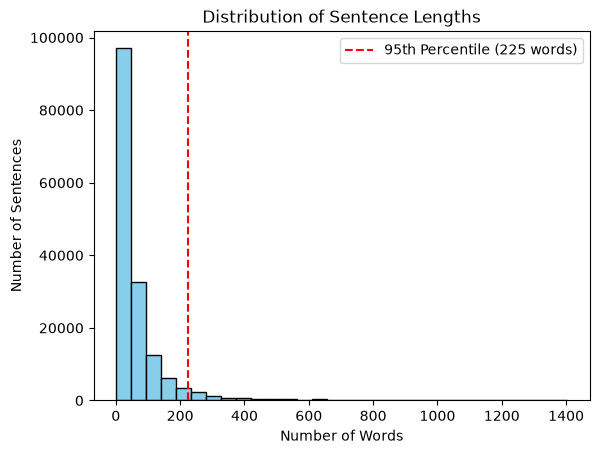

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the word count for every single row
sentence_lengths = df['text'].apply(lambda x: len(str(x).split()))

# 2. Find the mathematical 95th percentile
calculated_max_len = int(np.percentile(sentence_lengths, 95))

print(f"95% of all sentences in this dataset are {calculated_max_len} words or shorter!")
print(f"Therefore, setting MAX_LEN = {calculated_max_len} is data-driven because it preserves whole sentences for 95% of our data.")

# 3. Optional: Plot a histogram to show your mentor in your presentation
plt.hist(sentence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.axvline(calculated_max_len, color='red', linestyle='--', label=f'95th Percentile ({calculated_max_len} words)')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Sentences')
plt.legend()
plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

MAX_VOCAB_SIZE = 10000
MAX_LEN = 100
BATCH_SIZE = 64

# Initialize vectorizer
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation' 
)

# Adapt to the full dataset column
vectorizer.adapt(df['text'].values)
X_sequences = vectorizer(df['text'].values)
y_labels = df['is_toxic'].values

# Create optimized dataset pipeline
dataset = tf.data.Dataset.from_tensor_slices((X_sequences, y_labels))
train_dataset = dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f" Processed {X_sequences.shape[0]} rows")

 Processed 159557 rows


### Finally, time for the RNN Model

I built Vanilla RNN AKA Simple RNN

Since that the dataset is large, so I chose the no of epochs to be only 2, however for other way smaller datasets i chose 20 up to 60 epochs , so it depends on the dataset size and how clean it is 

In [23]:
from tensorflow.keras.layers import TextVectorization, Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
# Add .numpy() to convert the Tensor to a NumPy array
X_sequences = vectorizer(df['text'].values).numpy()
X_train, X_val, y_train, y_val = train_test_split(
    X_sequences, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Create Optimized tf.data.Dataset Pipelines
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build and Compile Vanilla RNN
rnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model with Validation Data
print("=== Training Vanilla RNN ===")
rnn_history = rnn_model.fit(train_dataset, validation_data=val_dataset, epochs=2)


=== Training Vanilla RNN ===
Epoch 1/2


d:\MiniCondaaaa\envs\summer26\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
d:\MiniCondaaaa\envs\summer26\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1995/1995 ━━━━━━━━━━━━━━━━━━━━ 57s 28ms/step - accuracy: 0.8977 - loss: 0.3280 - val_accuracy: 0.8997 - val_loss: 0.3193
Epoch 2/2
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9004 - loss: 0.3133 - val_accuracy: 0.9002 - val_loss: 0.3217


Another point to put into consideration is that I did not remove the stop words,when I searched I found out that in toxicity classification, it is better not to remove prepositions or pronouns because it might be essential for the whole meaning or the sentence. Another reason is that on a previous dataset I trained the model twice, once with stop words and another without, and it appeared that without the stop words the accuracy was a little bit lower.

In [24]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,877,253 (14.79 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,584,836 (9.86 MB)

### Graphs to plot the accuracy of our model

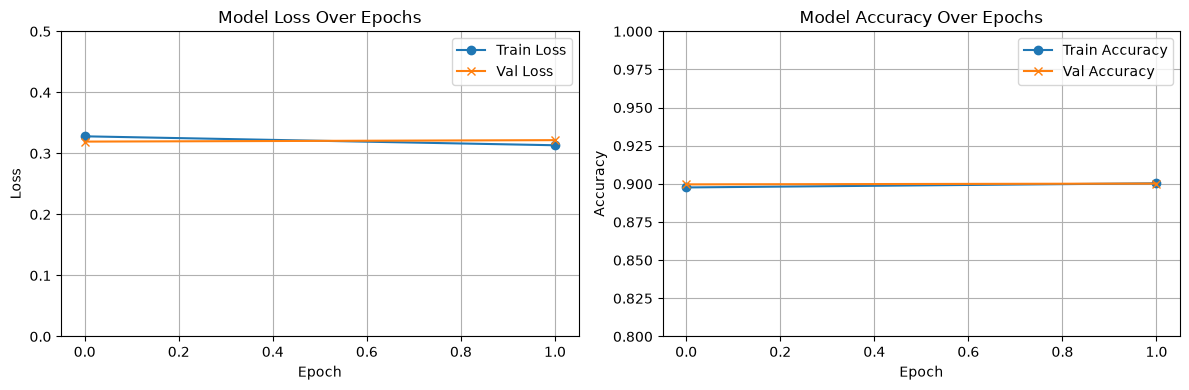

499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Clean       0.90      1.00      0.95     28667
       Toxic       0.71      0.03      0.06      3245

    accuracy                           0.90     31912
   macro avg       0.81      0.52      0.50     31912
weighted avg       0.88      0.90      0.86     31912



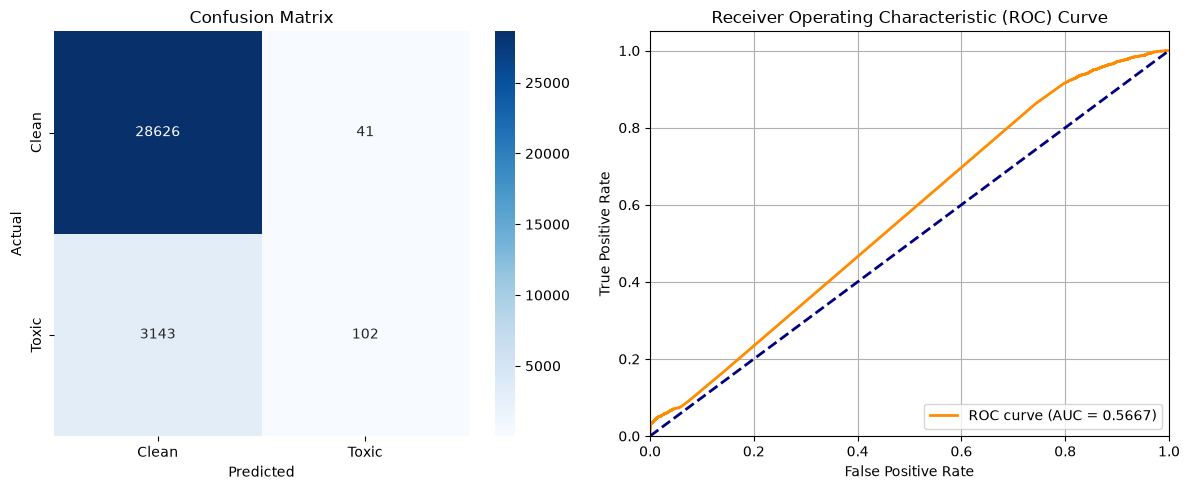

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score


# Plot training history (loss & accuracy)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss Curves
axes[0].plot(rnn_history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(rnn_history.history['val_loss'], label='Val Loss', marker='x')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(0, 0.5)
axes[0].legend()
axes[0].grid(True)

# Accuracy Curves
axes[1].plot(rnn_history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(rnn_history.history['val_accuracy'], label='Val Accuracy', marker='x')
axes[1].set_title('Model Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

current_model = rnn_model  

y_pred_probs = current_model.predict(val_dataset).flatten()
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_val, y_pred_labels, target_names=['Clean', 'Toxic']))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clean', 'Toxic'], yticklabels=['Clean', 'Toxic'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()